# Notebook 04 - Covariance Matrix

## Goal

Construct the covariance matrix

Study

- Why covariance has this form
- Signal covariance
- Noise covariance
- Effect of SNR
- Matrix structure

This notebook corresponds to Section 2 of the paper.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

In [19]:
# ===================================
# Radar Parameters
# ===================================

fs = 20e6
T = 20e-6
B = 5e6

N = int(fs*T)

k = B/T

print("N =", N)

N = 400


In [20]:
t = np.arange(N)/fs

t = t - T/2

s = np.exp(1j*np.pi*k*t**2)

In [21]:
def delay_signal(signal, delay):

    delayed = np.zeros_like(signal)

    delayed[delay:] = signal[:-delay]

    return delayed

In [22]:
taus = [30,100,220]

signals = []

for tau in taus:

    signals.append(
        delay_signal(s,tau)
    )

S = np.column_stack(signals)

print(S.shape)

(400, 3)


In [23]:
signal_covariance = S @ S.conj().T

print(signal_covariance.shape)

(400, 400)


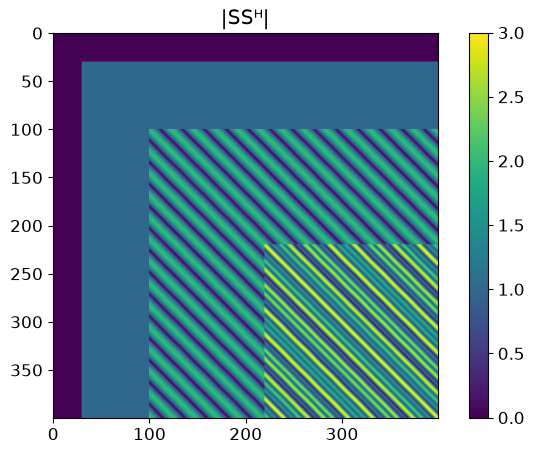

In [24]:
plt.figure()

plt.imshow(np.abs(signal_covariance))

plt.colorbar()

plt.title("|SSᴴ|")

plt.show()

In [26]:
sigma_noise = 1.0

sigma_alpha = 1.0

R = sigma_noise**2*np.eye(N,dtype=np.complex128)

R += sigma_alpha**2*signal_covariance

In [27]:
print(R.shape)

(400, 400)


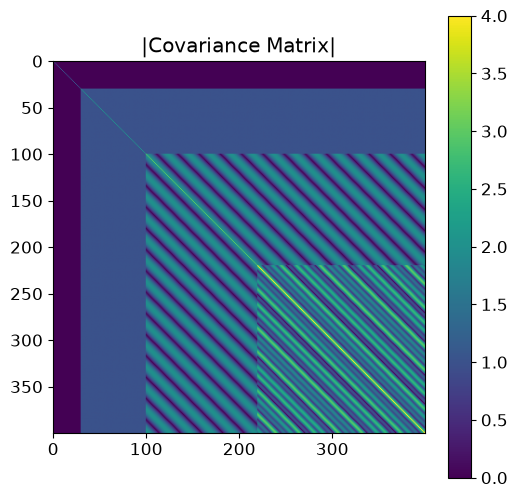

In [28]:
plt.figure(figsize=(6,6))

plt.imshow(np.abs(R))

plt.colorbar()

plt.title("|Covariance Matrix|")

plt.show()

Text(0.5, 1.0, 'Diagonal Entries')

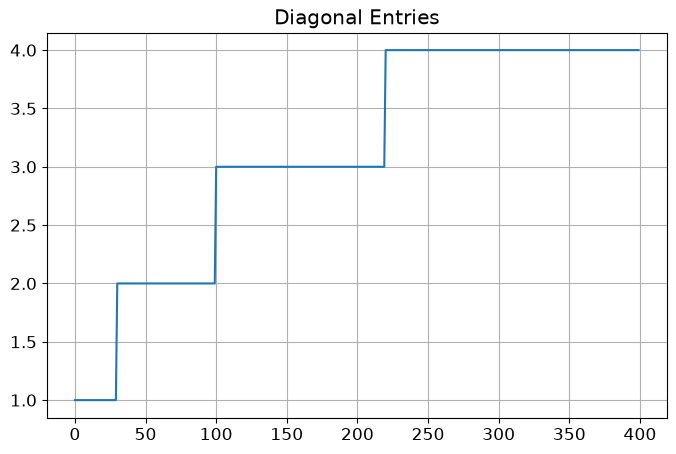

In [29]:
plt.figure()

plt.plot(np.real(np.diag(R)))

plt.grid()

plt.title("Diagonal Entries")

In [ ]:
error = np.max(
    np.abs(
        R-R.conj().T
    )
)

print(error)

4.965068306494546e-16


In [32]:
eigvals = np.linalg.eigvalsh(R)
print(np.min(eigvals))

0.9999999999998361


In [33]:
cond=np.linalg.cond(R)

print(cond)

371.14842119252523


In [34]:
A=S@S.conj().T

G=S.conj().T@S

eigA=np.linalg.eigvalsh(A)

eigG=np.linalg.eigvalsh(G)
eigA_nonzero=eigA[eigA>1e-8]
print(eigA_nonzero)

print(eigG)

[179.81534851 300.0362303  370.14842119]
[179.81534851 300.0362303  370.14842119]
